In [182]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_auc_score
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split

### Use a Python notebook & Load the dataset

In [183]:
#Load the file from local directory which is a special form of read_table
pk_df = pd.read_csv("parkinsons.data")

### It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)

In [184]:
pk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [185]:
pk_df.head().T

,0,1,2,3,4
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3,phon_R01_S01_4,phon_R01_S01_5
MDVP:Fo(Hz),119.992,122.4,116.682,116.676,116.014
MDVP:Fhi(Hz),157.302,148.65,131.111,137.871,141.781
MDVP:Flo(Hz),74.997,113.819,111.555,111.366,110.655
MDVP:Jitter(%),0.00784,0.00968,0.0105,0.00997,0.01284
MDVP:Jitter(Abs),7e-05,8e-05,9e-05,9e-05,0.00011
MDVP:RAP,0.0037,0.00465,0.00544,0.00502,0.00655
MDVP:PPQ,0.00554,0.00696,0.00781,0.00698,0.00908
Jitter:DDP,0.01109,0.01394,0.01633,0.01505,0.01966
MDVP:Shimmer,0.04374,0.06134,0.05233,0.05492,0.06425


##### Brief Description of the Data:
##### * "Name" independent attribute is of Object-Type. This will not influence the model and hence, need to be dropped.
##### * All other independent attributes are Continous-Numerical. 
##### * "Status" is a dependent variable and it's of type Binary-Categorical

### Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)

##### Univariate: Individual attributes spread depicted below using histogram and mean

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000000141F69B0>,
      dtype=object)

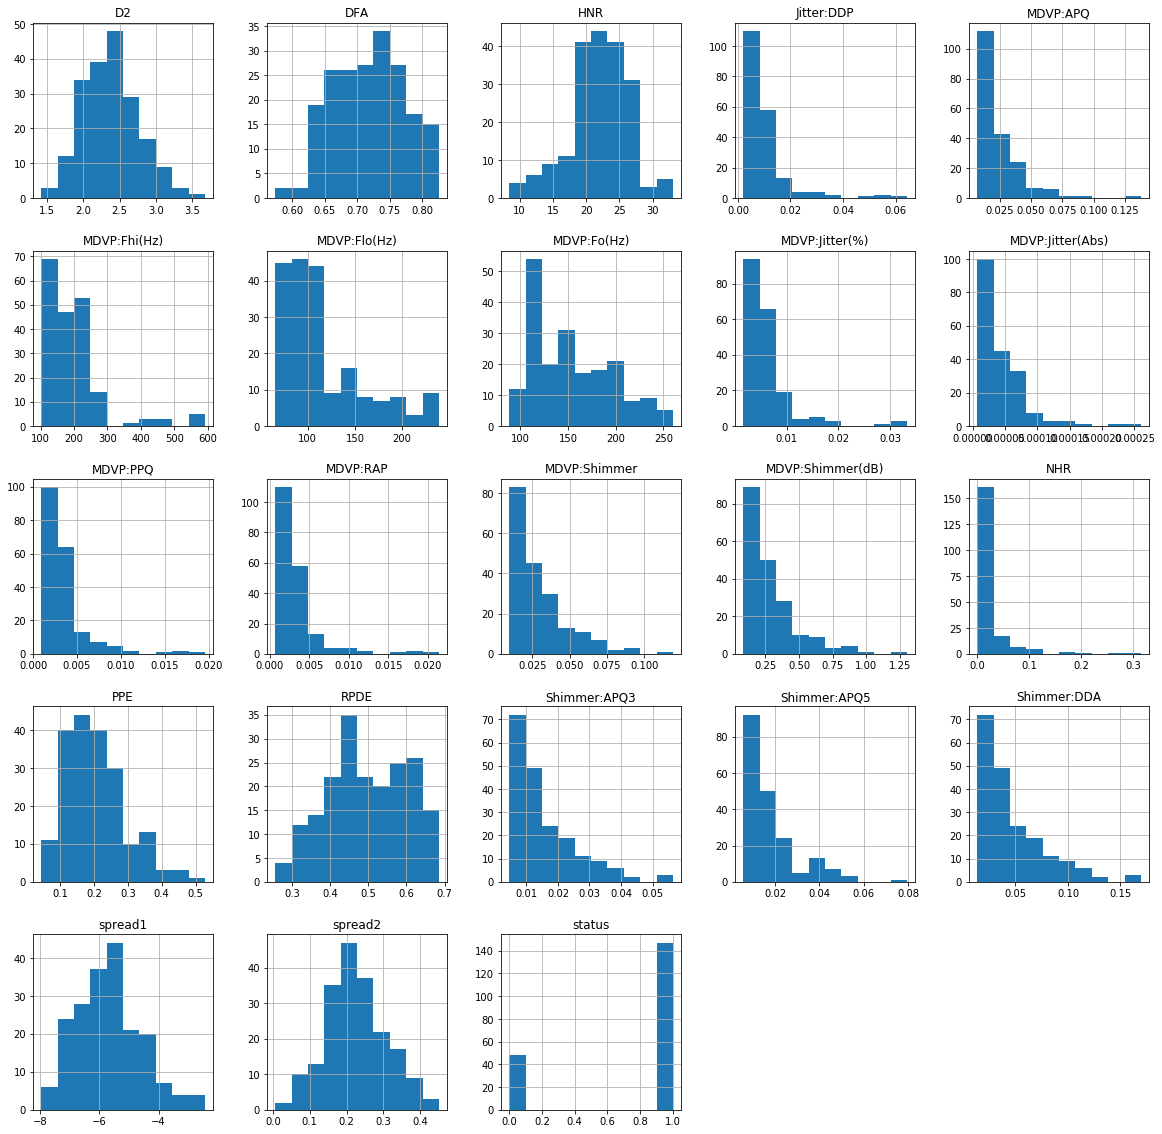

In [186]:
pk_df.hist(figsize=(20,20))

In [187]:
pk_df.mean()

MDVP:Fo(Hz)         154.228641
MDVP:Fhi(Hz)        197.104918
MDVP:Flo(Hz)        116.324631
MDVP:Jitter(%)        0.006220
MDVP:Jitter(Abs)      0.000044
MDVP:RAP              0.003306
MDVP:PPQ              0.003446
Jitter:DDP            0.009920
MDVP:Shimmer          0.029709
MDVP:Shimmer(dB)      0.282251
Shimmer:APQ3          0.015664
Shimmer:APQ5          0.017878
MDVP:APQ              0.024081
Shimmer:DDA           0.046993
NHR                   0.024847
HNR                  21.885974
status                0.753846
RPDE                  0.498536
DFA                   0.718099
spread1              -5.684397
spread2               0.226510
D2                    2.381826
PPE                   0.206552
dtype: float64

##### Bivariate: Correlation of each independent attribute with other attribute below

In [188]:
corr = pk_df.corr()
corr

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383535,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.166136,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.380200,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.278220,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.338653,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.266668,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.288698,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.266646,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.367430,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.350697,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


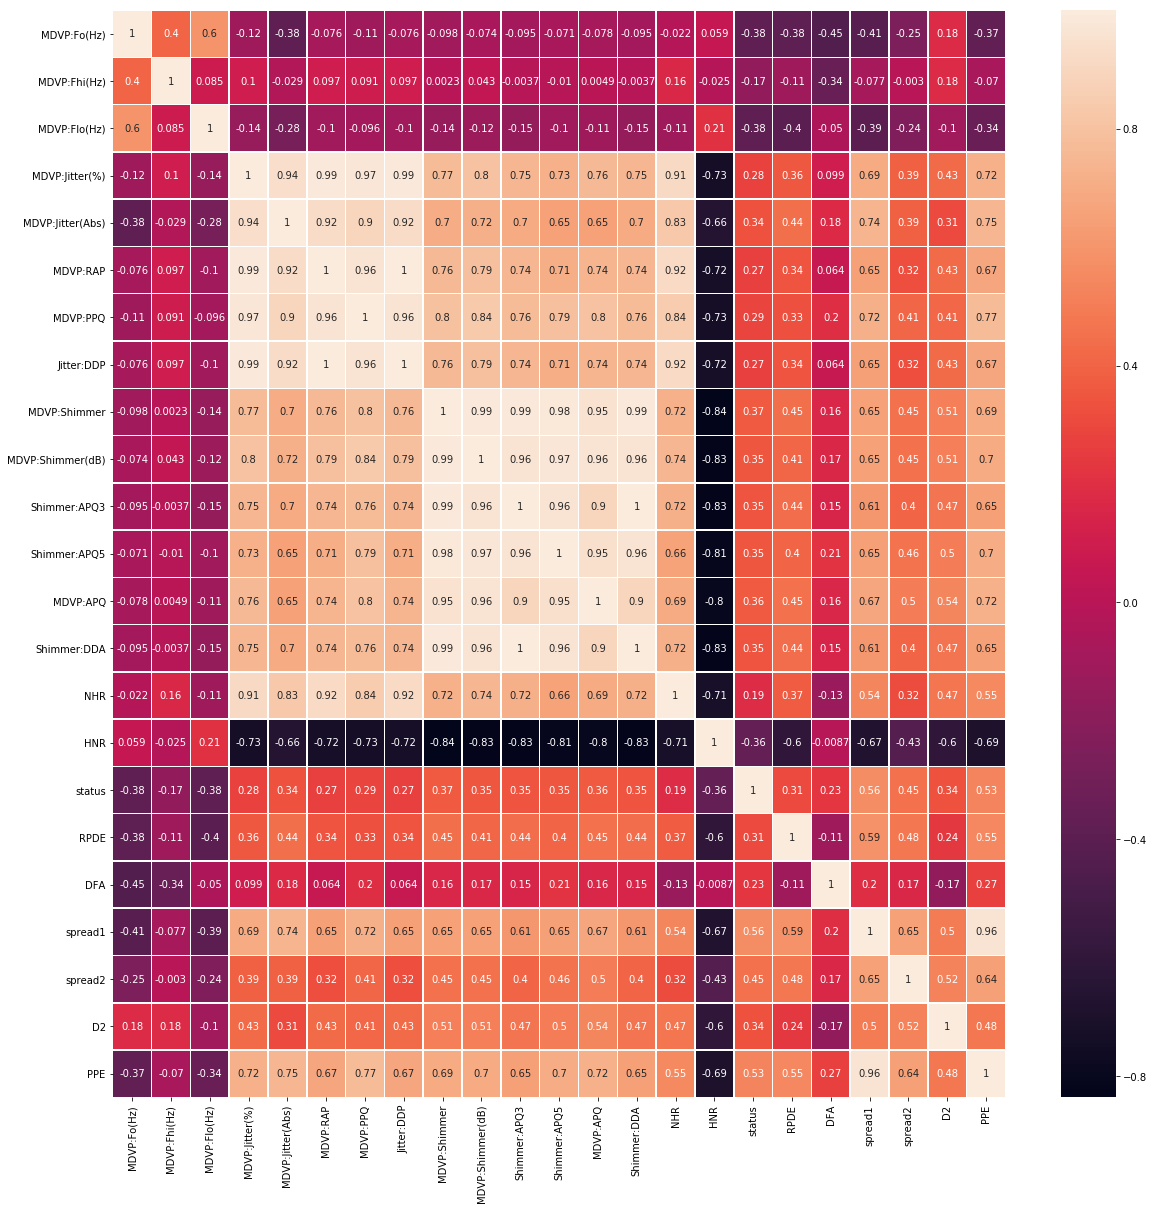

In [189]:
fig, ax = plt.subplots(figsize=(20,20))         # Sample figsize in inches
sns.heatmap(corr, annot=True, linewidths=.5, ax=ax)

##### Correlation between independent attributes MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP is > 0.9. So, only keep one independent attribute from this list 'MDVP:Jitter(%)' and  drop the remaining attributes

In [62]:
drop_feature_list = []
drop_feature_list.extend (['MDVP:Jitter(Abs)','MDVP:RAP','MDVP:PPQ','Jitter:DDP'])

##### Correlation between independent attributes MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA  is > 0.9. So, only keep one inpependent attribute from this list 'MDVP:Shimmer' and  drop the remaining attributes

In [190]:
drop_feature_list.extend (['MDVP:Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5','MDVP:APQ','Shimmer:DDA'])

##### Correlation between independent attribute 'spread1' and 'PPE' is >0.9. Drop one of the attributes

In [191]:
drop_feature_list.append ('PPE')

In [192]:
# Drop name object as it's not influencing the dependent variable
drop_feature_list.append ('name')

In [193]:
# Drop the dependent variable 'status' as well
drop_feature_list.append ('status')
drop_feature_list

['MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'PPE',
 'name',
 'status',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'PPE',
 'name',
 'status']

In [194]:
# Create a separate dataframe consisting only independent attributes. Also remove the above attributes which have low correlation
X = pk_df.drop(labels = drop_feature_list, axis = 1)

In [195]:
X.head().T

,0,1,2,3,4
MDVP:Fo(Hz),119.992000,122.400000,116.682000,116.676000,116.014000
MDVP:Fhi(Hz),157.302000,148.650000,131.111000,137.871000,141.781000
MDVP:Flo(Hz),74.997000,113.819000,111.555000,111.366000,110.655000
MDVP:Jitter(%),0.007840,0.009680,0.010500,0.009970,0.012840
MDVP:Shimmer,0.043740,0.061340,0.052330,0.054920,0.064250
NHR,0.022110,0.019290,0.013090,0.013530,0.017670
HNR,21.033000,19.085000,20.651000,20.644000,19.649000
RPDE,0.414783,0.458359,0.429895,0.434969,0.417356
DFA,0.815285,0.819521,0.825288,0.819235,0.823484
spread1,-4.813031,-4.075192,-4.443179,-4.117501,-3.747787


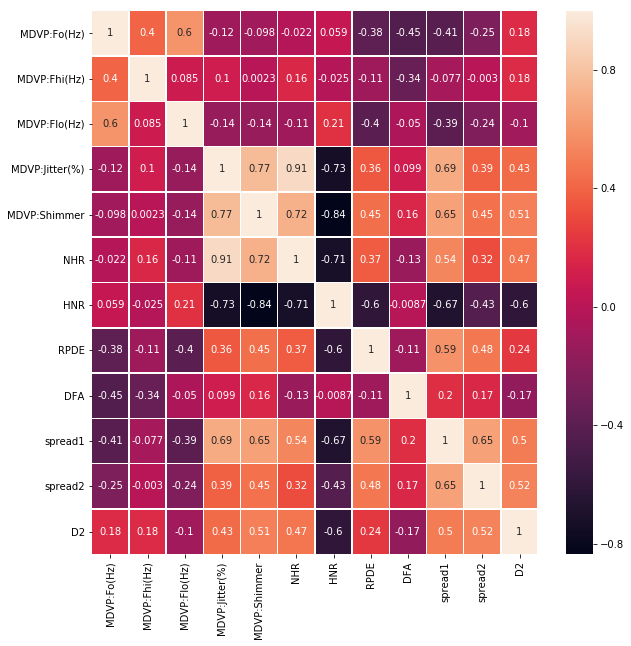

In [196]:
X_corr = X.corr()
fig, ax = plt.subplots(figsize=(10,10))         # Sample figsize in inches
sns.heatmap(X_corr, annot=True, linewidths=.5, ax=ax)

##### As seen above, most of the independent attributes with corr >0.9 have been removed from the feature-set for the model. This will ensure the model can be deduced based on lesses number of attributes and save processing overhead 

In [197]:
# Normalize the data for the model 
X = X.apply(zscore)

In [198]:
X.head().T

,0,1,2,3,4
MDVP:Fo(Hz),-0.829300,-0.770972,-0.909476,-0.909622,-0.925657
MDVP:Fhi(Hz),-0.436165,-0.530974,-0.723168,-0.649092,-0.606245
MDVP:Flo(Hz),-0.952037,-0.057721,-0.109875,-0.114229,-0.130608
MDVP:Jitter(%),0.334914,0.715418,0.884991,0.775389,1.368893
MDVP:Shimmer,0.745985,1.681731,1.202693,1.340396,1.836448
NHR,-0.067893,-0.137843,-0.291633,-0.280719,-0.178026
HNR,-0.193225,-0.634508,-0.279760,-0.281346,-0.506745
RPDE,-0.807838,-0.387524,-0.662075,-0.613134,-0.783021
DFA,1.760814,1.837562,1.942048,1.832380,1.909364
spread1,0.801323,1.479853,1.141445,1.440945,1.780940


In [199]:
# Capture the class values from the 'status' 
y = pk_df['status']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: status, dtype: int64

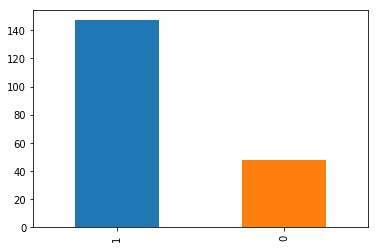

In [200]:
# barplot to analyze the distribution of dependent variable 'status'  
y.value_counts().plot(kind = 'bar')

### Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [219]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)

In [220]:
model_dtc = DecisionTreeClassifier(criterion='entropy',random_state=seed)
model_dtc.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=7,
            splitter='best')

### Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)

In [221]:
ypred = model_dtc.predict(X_test)
testAccuracy = accuracy_score(y_test, ypred)
testRecall = recall_score(y_test, ypred)
testPrecision = precision_score(y_test, ypred)
testF1score = f1_score(y_test, ypred)

ResultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score"])
optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]

# Concatenate Test results to resultsDf
ResultsDf["DT-TestResult"] = optimalTestResults
ResultsDf

,DT-TestResult
dataSize,59.000000
accuracy,0.847458
recall,0.851064
precision,0.952381
f1_score,0.898876


In [222]:
# Predicted value of 'status' for the X-Test 
ypred

array([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0], dtype=int64)

In [223]:
X_test.head().T

,191,120,24,117,2
MDVP:Fo(Hz),1.339202,-0.612556,0.228355,0.400335,-0.909476
MDVP:Fhi(Hz),0.612690,3.096674,0.040940,2.773958,-0.723168
MDVP:Flo(Hz),-0.618218,-0.646714,-0.910987,-0.859086,-0.109875
MDVP:Jitter(%),-0.120037,-0.084882,0.248060,-0.138649,0.884991
MDVP:Shimmer,-0.116922,-0.511956,-0.697510,-0.662419,1.202693
NHR,-0.167360,-0.033414,-0.175298,-0.169345,-0.291633
HNR,-0.620463,0.647206,0.440609,0.861731,-0.279760
RPDE,-0.644916,-0.103974,-0.970327,-0.113794,-0.662075
DFA,-0.631503,-0.615451,0.260536,-0.762333,1.942048
spread1,-0.469859,-0.461401,0.116745,0.999222,1.141445


##### Crosstab of y_test and y_predict 

In [224]:
pd.crosstab(y_test, ypred, margins=True)

col_0,0,1,All
status,,,
0,10,2,12
1,7,40,47
All,17,42,59


### Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points) 

In [225]:
#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion':['entropy']}
GS=GridSearchCV(model_dtc,parameter,cv=3)
GS.fit(X_train,y_train)

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=7,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [226]:
gs_pred=GS.predict(X_test)
testAccuracy = accuracy_score(y_test, gs_pred)
testRecall = recall_score(y_test, gs_pred)
testPrecision = precision_score(y_test, gs_pred)
testF1score = f1_score(y_test, gs_pred)
optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]

# Concatenate Test results to resultsDf
ResultsDf["GS-TestResult"] = optimalTestResults
ResultsDf

,DT-TestResult,GS-TestResult
dataSize,59.000000,59.000000
accuracy,0.847458,0.847458
recall,0.851064,0.851064
precision,0.952381,0.952381
f1_score,0.898876,0.898876


In [227]:
GS.best_params_

{'criterion': 'entropy', 'max_depth': 7}

##### Optimial max-depth for Decision-Tree is 7

In [228]:
# Use the max-depth as 7 and recalculate the DT model 
model_dtc_optdepth = DecisionTreeClassifier(criterion = 'entropy', max_depth=7,random_state=seed)
model_dtc_optdepth.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=7,
            splitter='best')

In [229]:
ypred = model_dtc_optdepth.predict(X_test)

testAccuracy = accuracy_score(y_test, ypred)
testRecall = recall_score(y_test, ypred)
testPrecision = precision_score(y_test, ypred)
testF1score = f1_score(y_test, ypred)

optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]

# Concatenate Test results to resultsDf
ResultsDf["DT-OptDepth-TestResult"] = optimalTestResults
ResultsDf

,DT-TestResult,GS-TestResult,DT-OptDepth-TestResult
dataSize,59.000000,59.000000,59.000000
accuracy,0.847458,0.847458,0.847458
recall,0.851064,0.851064,0.851064
precision,0.952381,0.952381,0.952381
f1_score,0.898876,0.898876,0.898876


In [230]:
# Use the min_samples_leaf=2 and check the impact on the model
model_dtc_minsampleleaf = DecisionTreeClassifier(criterion = 'entropy', max_depth=7, min_samples_leaf=2, random_state=seed)
model_dtc_minsampleleaf.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=7,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=2, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=7,
            splitter='best')

In [231]:
ypred = model_dtc_minsampleleaf.predict(X_test)

testAccuracy = accuracy_score(y_test, ypred)
testRecall = recall_score(y_test, ypred)
testPrecision = precision_score(y_test, ypred)
testF1score = f1_score(y_test, ypred)
optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]

# Concatenate Test results to resultsDf
ResultsDf["DT-MinSampleLeaf-2-TestResult"] = optimalTestResults
ResultsDf

,DT-TestResult,GS-TestResult,DT-OptDepth-TestResult,DT-MinSampleLeaf-2-TestResult
dataSize,59.000000,59.000000,59.000000,59.000000
accuracy,0.847458,0.847458,0.847458,0.830508
recall,0.851064,0.851064,0.851064,0.829787
precision,0.952381,0.952381,0.952381,0.951220
f1_score,0.898876,0.898876,0.898876,0.886364


### Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)

In [232]:
#Bootstrapped sampled multiple decision tree(with the hope of controlling bias error)
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=seed)
Rf_model.fit(X_train, y_train)
ypred = Rf_model.predict(X_test)

testAccuracy = accuracy_score(y_test, ypred)
testRecall = recall_score(y_test, ypred)
testPrecision = precision_score(y_test, ypred)
testF1score = f1_score(y_test, ypred)
optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]

# Concatenate Test results to resultsDf
ResultsDf["RF-TestResult"] = optimalTestResults
ResultsDf

,DT-TestResult,GS-TestResult,DT-OptDepth-TestResult,DT-MinSampleLeaf-2-TestResult,RF-TestResult
dataSize,59.000000,59.000000,59.000000,59.000000,59.000000
accuracy,0.847458,0.847458,0.847458,0.830508,0.915254
recall,0.851064,0.851064,0.851064,0.829787,0.978723
precision,0.952381,0.952381,0.952381,0.951220,0.920000
f1_score,0.898876,0.898876,0.898876,0.886364,0.948454


In [233]:
# random forest should have a number of trees between 64 - 128 trees. We will iterate between these and find the optimal accuracy-score 

opt_auc_score = 0 
for n_est in range(64,128):
    Rf_model = RandomForestClassifier(n_est,criterion='entropy', oob_score = 'TRUE', random_state=seed)
    Rf_model.fit(X_train, y_train)
    ypred = Rf_model.predict(X_test)
    auc_score = roc_auc_score(y_test, ypred)
    if auc_score > opt_auc_score:
        opt_auc_score = auc_score
        #print ('Opt-AUC-Score:={} Opt_N_Estimaters:={}\n'.format(opt_auc_score, n_est))
print ('\n\n *Opt_N_Estimaters={} *Opt-AUC-Score={} \n'.format(n_est, opt_auc_score))



 *Opt_N_Estimaters=127 *Opt-AUC-Score=0.8333333333333334 



##### Optimal Estimaters is 127 Decision-Trees. This is based on the ROC_AUC Score

#### Description of the results for the Random Forest model:
##### * Accuracy (.91): Model can predict at 91% accurary number of patients "with-PD + without-PD" w.r.t the total number of patients 
##### * Recall (0.97): Model can predict at 97% the number of patients with "PD"  among the total number of pateints who actually have "PD"
##### * Precision (0.92): Model can predict at 92%, among all the patients with "PD", how many actually have "PD"
##### * Precision indicates the Type-1 Error. Recall indicates the Type-II Error.